In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]]
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


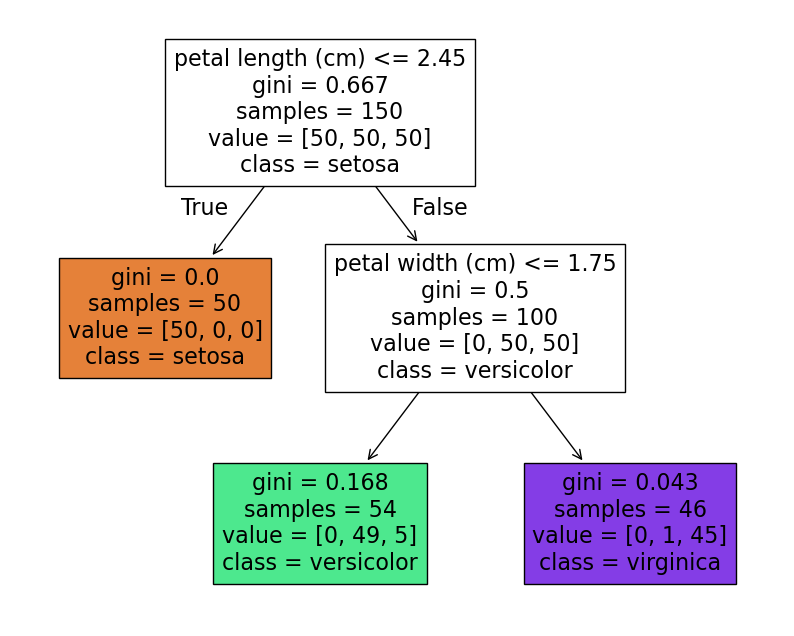

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_tree(tree_clf, feature_names=X_iris.columns , class_names= iris.target_names, filled=True)
plt.show()

In [22]:
# 지니계수 : 데이터의 순도 측정
# 순도가 높다 : 집단안에 같은 종류의 데이터만 모여있다 (지니계수 낮음)
# 불순도가 높다 : 여러종류의 데이터가 섞여있다 . (지니계수 높음)
# 데이터를 분할할때마다 지니계수가 낮아지는 방향으로 가지를 뻗어나간다. (지니계수 낮아지는 방향으로 가지가 뻗어나간다.)

In [23]:
from sklearn.model_selection import  train_test_split

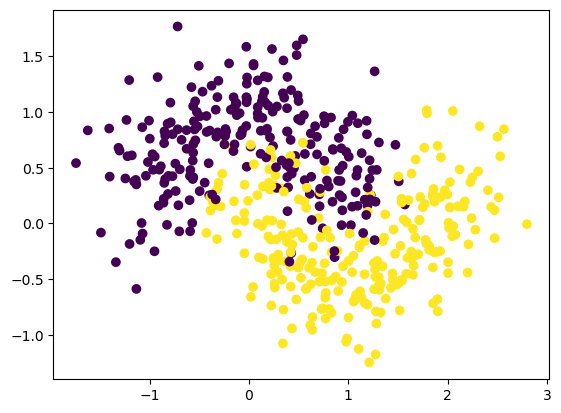

In [24]:
from sklearn.datasets import  make_moons
from sklearn.ensemble import  VotingClassifier , RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt

X,y = make_moons(n_samples=500, noise=0.30, random_state=42)
plt.scatter(X[:,0],X[:,1],c=y)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
models = [RandomForestClassifier(random_state=42), LogisticRegression(random_state=42), SVC(random_state=42)]

for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test,y_pred))

hard_voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(random_state=42)),
        ('lr', LogisticRegression(random_state=42)),
        ('svc', SVC(random_state=42))
        ], voting='hard'
)

hard_voting.fit(X_train, y_train)
y_pred = hard_voting.predict(X_test)
print('-' * 50)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88        43
           1       1.00      0.79      0.88        57

    accuracy                           0.88       100
   macro avg       0.89      0.89      0.88       100
weighted avg       0.91      0.88      0.88       100

              precision    recall  f1-score   support

           0       0.77      0.93      0.84        43
           1       0.94      0.79      0.86        57

    accuracy                           0.85       100
   macro avg       0.85      0.86      0.85       100
weighted avg       0.87      0.85      0.85       100

              precision    recall  f1-score   support

           0       0.77      1.00      0.87        43
           1       1.00      0.77      0.87        57

    accuracy                           0.87       100
   macro avg       0.88      0.89      0.87       100
weighted avg       0.90      0.87      0.87       100

-------------------

In [ ]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
rfc.predict_proba(X_test)

import numpy as np
np.argmax(rfc.predict_proba(X_test), axis=1)[:5] , rfc.predict(X_test)[:5]

(array([1, 0, 0, 1, 1]), array([1, 0, 0, 1, 1]))